# Метод опорных векторов (SVM): теория и практика

Этот ноутбук — теоретический и практический разбор алгоритма SVM. По аналогии с подходом, где используются синтетические данные для изолированной демонстрации эффектов, мы с нуля разберем максимизацию зазора, ядерный переход и оценку качества модели.

**Содержание:**
1. Геометрическая интуиция: гиперплоскости и максимизация зазора
2. Вариационное исчисление: Лагранжиан и условия Каруша-Куна-Таккера (KKT)
3. Двойственная задача и элементы функционального анализа (теорема Мерсера)
4. Реализация линейного SVM "с нуля" через градиентный спуск
5. Сравнение с использованием scikit-learn и оценка метрик
6. Ядровой трюк(Что делать, если данные неразделимы линейно)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(42)

## 1. Постановка задачи и максимизация зазора

Для обучающей выборки ищем разделяющую гиперплоскость $w^T x + b = 0$. Вектор w перпендикулярен разделяющей границе и определяет направление, вдоль которого производится классификация.Предсказанный класс для объекта $x_i$ определяется знаком скалярного выражения:

$$\hat{y}_i = \text{sign}(x_i^T w + b)$$

Если результат положителен, объект классифицируется как принадлежащий классу $+1$; если отрицателен — классу $-1$.

Цель алгоритма SVM — подобрать такие $w$ и $b$, чтобы предсказания совпадали с истинными метками.

$||w||$ - это минимальный зазор между ближайшими к границе объектами для нормированной гиперплоскости. Пусть гиперплоскость задана уравнением:

$$x^T w + b = 0$$

Расстояние от произвольной точки $x \in \mathbb{R}^n$ до этой гиперплоскости выражается формулой:

$$\text{dist}(x, H) = \frac{\vert{}x^T w + b\vert{}}{\Vert{}w\Vert{}}$$

Эта формула выводится следующим образом. Мы ищем проекцию точки $x$ на гиперплоскость $H$ вдоль нормали $w$. Искомая проекция имеет вид:

$$\text{proj}_H(x) = x - \lambda w$$

Где $\lambda$ — такое число, что $\text{proj}_H(x) \in H$, то есть:

$$(x - \lambda w)^T w + b = 0$$

Раскрывая скобки, получаем:

$$x^T w - \lambda w^T w + b = 0 \implies \lambda = \frac{x^T w + b}{\Vert{}w\Vert{}^2}$$

Теперь мы можем найти проекцию $\text{proj}_H(x)$:

$$\text{proj}_H(x) = x - \lambda w = x - \frac{x^T w + b}{\Vert{}w\Vert{}^2} w \implies \lambda w = \frac{x^T w + b}{\Vert{}w\Vert{}^2} w$$

Значит, вектор от точки до гиперплоскости имеет длину:

$$\Vert{}x - \text{proj}_H(x)\Vert{} = \Vert{}\lambda w\Vert{} = \left\Vert{} \frac{x^T w + b}{\Vert{}w\Vert{}^2} w \right\Vert{} = \left\vert{} \frac{x^T w + b}{\Vert{}w\Vert{}^2} \right\vert{} \cdot \Vert{}w\Vert{} = \frac{\vert{}x^T w + b\vert{}}{\Vert{}w\Vert{}}$$

Таким образом, расстояние от точки до гиперплоскости зависит только от значения $x^T w + b$, нормализованного по длине вектора $w$.

После нормировки $y_i(x_i^T w + b) \ge 1$ ближайшие точки лежат на гиперплоскостях:

$$x^T w + b = 1$$

$$x^T w + b = -1$$

Расстояние между этими двумя параллельными гиперплоскостями:

$$\frac{\vert{}1 - (-1)\vert{}}{\Vert{}w\Vert{}} = \frac{2}{\Vert{}w\Vert{}}$$

Это расстояние можно вывести геометрически через проекцию на вектор нормали: Выберем произвольную точку $x_1$, лежащую на первой гиперплоскости $H_1$, и точку $x_2$, лежащую на второй гиперплоскости $H_2$:

$$x_1^T w + b = 1 \implies x_1^T w = 1 - b$$

$$x_2^T w + b = -1 \implies x_2^T w = -1 - b$$

Вектор $w$ является перпендикуляром (нормалью) к обеим гиперплоскостям. Кратчайшее расстояние между двумя параллельными плоскостями — это длина проекции вектора $(x_1 - x_2)$, соединяющего эти точки, на нормаль $w$:

$$\text{dist}(H_1, H_2) = \frac{\vert{}(x_1 - x_2)^T w\vert{}}{\Vert{}w\Vert{}}$$

Раскроем скалярное произведение в числителе, подставив значения $x_1^T w$ и $x_2^T w$:

$$(x_1 - x_2)^T w = x_1^T w - x_2^T w = (1 - b) - (-1 - b) = 1 - (-1) = 2$$

Подставляем полученное значение обратно в формулу расстояния:

$$\text{dist}(H_1, H_2) = \frac{\vert{}2\vert{}}{\Vert{}w\Vert{}} = \frac{2}{\Vert{}w\Vert{}}$$

Мы хотим максимизировать зазор (margin) между классами, который геометрически равен $\frac{2}{||w||}$. Максимизация $\frac{2}{||w||}$ эквивалентна минимизации $\frac{1}{2} ||w||^2$.


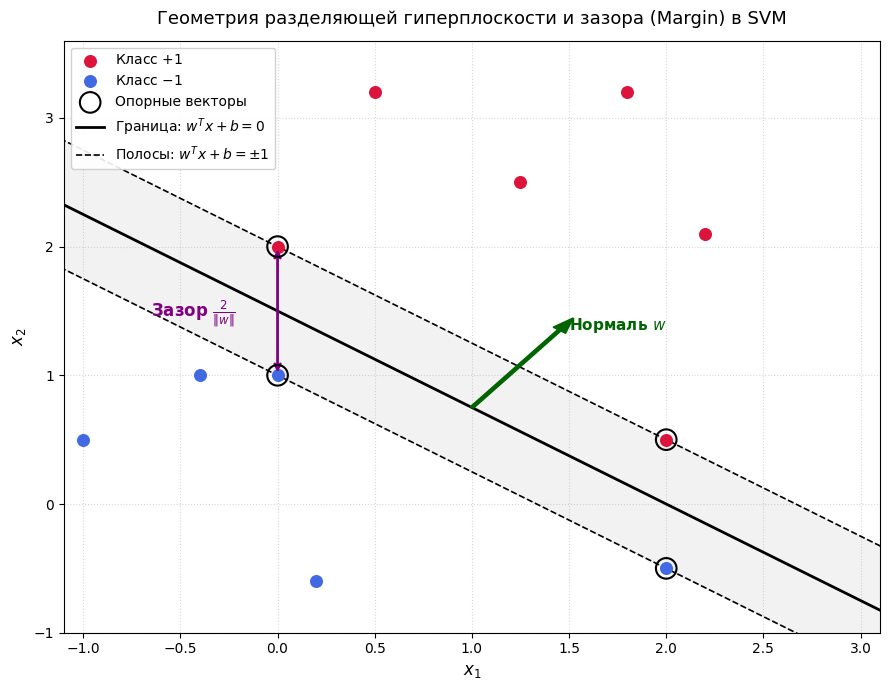

In [3]:
# 1. Параметры разделяющей гиперплоскости (w^T x + b = 0)
w = np.array([1.5,2.0])
b = -3.0

# 2. Данные для классов
np.random.seed(42)

# Точки класса +1 (w^T x + b >= 1)
X_pos = np.array([[1.25, 2.5], [2.2, 2.1], [0.5, 3.2], [1.8, 3.2]])
# Опороные векторы для класса +1(лежат строго на w^T x + b = 1)
SV_pos = np.array([[0.0,2.0],[2.0,0.5]])

# Точки класса -1 (w^T x + b < -1)
X_neg = np.array([[-1.0, 0.5], [0.2, -0.6], [-0.4, 1.0], [1.2, -1.2]])
# Опорные векторы для класса -1 (лежат строго на w^T x + b = -1)
SV_neg = np.array([[0.0, 1.0], [2.0, -0.5]])

# 3. Сетка для построения прямых линий: x2 = (c - b - w1*x1) / w2
x1_vals = np.linspace(-1.2, 3.2, 200)
line_main = (-b - w[0] * x1_vals) / w[1]  # w^T x + b = 0
line_plus = (1 - b - w[0] * x1_vals) / w[1]  # w^T x + b = 1
line_minus = (-1 - b - w[0] * x1_vals) / w[1]  # w^T x + b = -1

# 4. Отрисовка графика
plt.figure(figsize=(9, 7), dpi=100)

# Отображение точек классов
plt.scatter(
    X_pos[:, 0],
    X_pos[:, 1],
    color="crimson",
    s=70,
    label="Класс $+1$",
    zorder=3,
)
plt.scatter(SV_pos[:, 0], SV_pos[:, 1], color="crimson", s=70, zorder=3)

plt.scatter(
    X_neg[:, 0],
    X_neg[:, 1],
    color="royalblue",
    s=70,
    label="Класс $-1$",
    zorder=3,
)
plt.scatter(SV_neg[:, 0], SV_neg[:, 1], color="royalblue", s=70, zorder=3)

# Выделение опорных векторов кругами
SV_all = np.vstack([SV_pos, SV_neg])
plt.scatter(
    SV_all[:, 0],
    SV_all[:, 1],
    s=220,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Опорные векторы",
    zorder=4,
)

# Отрисовка границы и гиперплоскостей зазора
plt.plot(
    x1_vals,
    line_main,
    "k-",
    linewidth=2,
    label=r"Граница: $w^T x + b = 0$",
)
plt.plot(
    x1_vals,
    line_plus,
    "k--",
    linewidth=1.2,
    label=r"Полосы: $w^T x + b = \pm 1$",
)
plt.plot(x1_vals, line_minus, "k--", linewidth=1.2)

# Заливка области зазора (margin)
plt.fill_between(x1_vals, line_minus, line_plus, color="gray", alpha=0.1)

# Вектор нормали w (выходит из разделяющей линии)
x1_start, x2_start = 1.0, (-b - w[0] * 1.0) / w[1]
plt.arrow(
    x1_start,
    x2_start,
    w[0] * 0.3,
    w[1] * 0.3,
    head_width=0.08,
    head_length=0.12,
    fc="darkgreen",
    ec="darkgreen",
    width=0.02,
    zorder=5,
)
plt.text(
    x1_start + w[0] * 0.3 + 0.05,
    x2_start + w[1] * 0.3,
    r"Нормаль $w$",
    fontsize=11,
    color="darkgreen",
    fontweight="bold",
)

# Стрелка ширины зазора 2/||w||
p1, p2 = np.array([0.0, 2.0]), np.array([0.0, 1.0])
plt.annotate(
    "",
    xy=p1,
    xytext=p2,
    arrowprops=dict(arrowstyle="<->", color="purple", lw=2),
)
plt.text(
    -0.65,
    1.45,
    r"Зазор $\frac{2}{\|w\|}$",
    fontsize=12,
    color="purple",
    fontweight="bold",
)

# Оформление графика
plt.xlim(-1.1, 3.1)
plt.ylim(-1.0, 3.6)
plt.xlabel(r"$x_1$", fontsize=12)
plt.ylabel(r"$x_2$", fontsize=12)
plt.title(
    "Геометрия разделяющей гиперплоскости и зазора (Margin) в SVM",
    fontsize=13,
    pad=12,
)
plt.legend(loc="upper left", framealpha=0.9)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 2. Вариационное исчисление: Лагранжиан и условия KKT

Задача условной оптимизации (Primal problem) для линейно разделимой выборки формулируется так:

$$\min_{w, b} \frac{1}{2} ||w||^2$$
при ограничениях: $y_i(w^T x_i + b) \ge 1 \quad \forall i$.

Используя методы вариационного исчисления, вводим множители Лагранжа $\alpha_i \ge 0$. Функция Лагранжа принимает вид:
$$\mathcal{L}(w, b, \alpha) = \frac{1}{2} ||w||^2 - \sum_{i=1}^n \alpha_i [y_i(w^T x_i + b) - 1]$$

Согласно условиям Каруша-Куна-Таккера (KKT), приравниваем к нулю производные по $w$ и $b$:
$$w = \sum_{i=1}^n \alpha_i y_i x_i \quad \text{и} \quad \sum_{i=1}^n \alpha_i y_i = 0$$

## 3. Двойственная задача и Функциональный анализ

Подстановка условий KKT обратно в Лагранжиан дает нам Двойственную задачу (Dual problem), которая зависит исключительно от скалярных произведений $\langle x_i, x_j \rangle$:

$$\max_{\alpha} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j (x_i^T x_j)$$

Для линейно неразделимых данных применяется **Kernel Trick** (ядерный переход). В контексте функционального анализа и **теоремы Мерсера**, любая непрерывная, симметричная и положительно определенная функция $K(x, z)$ может быть представлена как скалярное произведение в некотором гильбертовом пространстве (RKHS). Это позволяет нам напрямую заменить $x_i^T x_j$ на функцию ядра $K(x_i, x_j)$, неявно перенося данные в бесконечномерное пространство для линейного разделения.

## 4. Реализация линейного SVM "с нуля"

На практике при проектировании пайплайнов алгоритм часто реализуют с использованием Hinge Loss функции и градиентного (или субградиентного) спуска. Ниже представлена реализация архитектуры базовой модели с нуля.

In [1]:
class SVM_from_scratch:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # Условие удовлетворения Hinge Loss (margin >= 1)
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y[idx]))
                    self.b -= self.lr * y[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

## 5. Сравнение со scikit-learn и оценка метрик

Используем сгенерированные синтетические данные для валидации нашей реализации и сравнения её с эталонной моделью `SVC` из библиотеки `scikit-learn`.

In [4]:
# Генерация линейно разделимых синтетических данных
X, y = make_classification(n_samples=300, n_features=2, n_informative=2, 
                           n_redundant=0, n_clusters_per_class=1, random_state=42)
# Для SVM метки классов должны быть -1 и 1
y = np.where(y == 0, -1, 1)

# Обучение реализации "с нуля"
model_scratch = SVM_from_scratch(n_iters=2000)
model_scratch.fit(X, y)

# Обучение scikit-learn модели
model_sklearn = SVC(kernel='linear', C=1.0)
model_sklearn.fit(X, y)

# Оценка метрик
print("Accuracy (модель с нуля):", accuracy_score(y, model_scratch.predict(X)))
print("Accuracy (scikit-learn):", accuracy_score(y, model_sklearn.predict(X)))

Accuracy (модель с нуля): 0.9233333333333333
Accuracy (scikit-learn): 0.9233333333333333


# 6. Ядровой трюк

Если данные неразделимы линейно, их можно отобразить в другое пространство — возможно, гораздо большей размерности — с помощью отображения $\phi(x)$. Тогда все скалярные произведения $x_i^T x_j$ заменяются на $\phi(x_i)^T \phi(x_j)$.

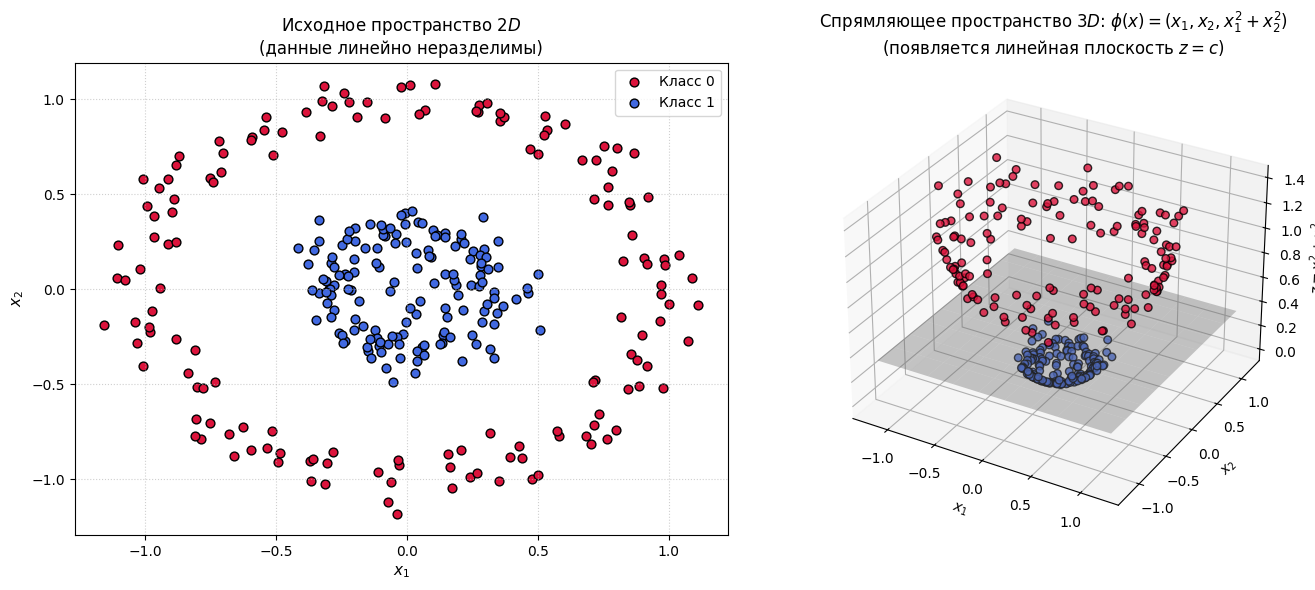

In [ ]:
from sklearn.datasets import make_circles

# 1. Генерация нелинейно разделимых данных (концентрические окружности)
X, y = make_circles(n_samples=300, factor=0.3, noise=0.08, random_state=42)

# 2. Перевод в 3D пространство с помощью отображения phi(x1, x2) = (x1, x2, x1^2 + x2^2)
z = X[:, 0] ** 2 + X[:, 1] ** 2

# 3. Построение графиков
fig = plt.figure(figsize=(14, 6), dpi=100)

# Левый график: Исходное 2D пространство
ax1 = fig.add_subplot(121)
ax1.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="crimson",
    edgecolors="k",
    s=40,
    label="Класс 0",
)
ax1.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="royalblue",
    edgecolors="k",
    s=40,
    label="Класс 1",
)
ax1.set_title(
    "Исходное пространство $2D$\n(данные линейно неразделимы)", fontsize=12
)
ax1.set_xlabel("$x_1$", fontsize=11)
ax1.set_ylabel("$x_2$", fontsize=11)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# Правый график: Спрямляющее 3D пространство
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    z[y == 0],
    color="crimson",
    edgecolors="k",
    s=30,
    alpha=0.8,
)
ax2.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    z[y == 1],
    color="royalblue",
    edgecolors="k",
    s=30,
    alpha=0.8,
)

# Разделяющая плоскость в 3D (z = 0.35)
x1_grid, x2_grid = np.meshgrid(
    np.linspace(-1.2, 1.2, 10), np.linspace(-1.2, 1.2, 10)
)
z_plane = np.full_like(x1_grid, 0.35)
ax2.plot_surface(
    x1_grid, x2_grid, z_plane, color="gray", alpha=0.35, edgecolor="none"
)

ax2.set_title(
    "Спрямляющее пространство $3D$: $\phi(x) = (x_1, x_2, x_1^2 + x_2^2)$\n(появляется линейная плоскость $z = c$)",
    fontsize=12,
)
ax2.set_xlabel("$x_1$", fontsize=10)
ax2.set_ylabel("$x_2$", fontsize=10)
ax2.set_zlabel("$z = x_1^2 + x_2^2$", fontsize=10)

plt.tight_layout()
plt.show()

Но если существует функция $K(x, x') = \phi(x)^T \phi(x')$, то можно вычислять это скалярное произведение напрямую в исходном пространстве, без явного построения самого отображения $\phi$. Это и есть **ядровой трюк** (kernel trick):

$$K(x, x') = \langle \phi(x), \phi(x') \rangle$$

Где $\phi(x)$ — отображение признаков в более богатое пространство. При этом явно вычислять $\phi$ не нужно: достаточно знать значение функции ядра $K(x, x')$.

**Типичные ядра:**
* **Полиномиальное:** $K(x, x') = (x^T x' + c)^d$
* **Гауссовское (RBF):** $K(x, x') = \exp\left(-\frac{\|x - x'\|^2}{2\sigma^2}\right)$
* **Сигмоидальное:** $K(x, x') = \tanh(k x^T x' + \theta)$

Модель остаётся линейной в новом пространстве, но реализует нелинейную разделяющую границу в исходном.